# Beginner Finance Dashboard
## ACC102 Mini Assignment – Track 4 Interactive Tool

This project is designed to help beginner investors understand companies through both market data and basic financial statement data.

The tool combines automatic analysis, concept explanation, comparison, and a beginner-friendly learning summary.

## 1. Problem Definition

Beginners often find it difficult to understand stock charts, company performance, and financial terms.

This project aims to build a beginner-friendly learning tool that uses real company data to explain both market performance and basic financial fundamentals.

It also includes a comparison function that allows users to compare two companies using financial information, helping them develop a clearer understanding of the market.


## 2. Intended User / Audience

This tool is designed for beginner investors and business students with limited prior knowledge of financial analysis.

## 3. Product Overview

Users select one or two companies and a time range. The system then produces automatic basic analysis, including price trend, return, volatility, revenue, net profit, profit margin, quick ratio, and current ratio.

Users can also choose an interpretation mode (**Beginner** or **Deeper**), explore key concepts, and read beginner-focused key takeaways.

## 4. Data Source

The data used in this project are retrieved from WRDS.  
This project combines market data and basic financial statement data in order to help beginner users understand both stock performance and company fundamentals.

Access date: 9 April 2026

## Optional package installation

If the required libraries are not available in the environment, please install them before running the notebook.

In [207]:
# Run this only if needed
!pip install matplotlib

## 5. Libraries and WRDS Connection

In this section, the required Python libraries are imported and the WRDS connection is established.

In [208]:
import wrds
import pandas as pd

In [209]:
username = "yuqingwu24"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [210]:
db.list_libraries()

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all',
 'boardex_trial',
 'boardsmp',
 'bvd',
 'bvd_amadeus_trial',
 'bvd_bvdbankf',
 'bvd_bvdbankf_trial',
 'bvd_orbis_trial',
 'bvdsamp',
 'calcbench_trial',
 'calcbnch',
 'candid_samp',
 'cboe',
 'cboe_all',
 'cboe_sample',
 'cboesamp',
 'cddsamp',
 'ciq',
 'ciq_capstrct',
 'ciq_common',
 'ciqsamp',
 'ciqsamp_capstrct',
 'ciqsamp_common',
 'ciqsamp_keydev',
 'ciqsamp_pplintel',
 'ciqsamp_ratings',
 'ciqsamp_transactions',
 'ciqsamp_transcripts',
 'cisdmsmp',
 'columnar',
 'comp',
 'comp_execucomp',
 'comp_global_daily',
 'comp_na_daily_all',
 'comp_urq',
 'comph',
 'compsamp',
 'compsamp_all',
 'compsamp_computext',
 'compsamp_snapshot',
 'contrib',
 'contrib_as_filed_financials',
 'contrib_bond_firm_link',
 'contrib_ceo_turnover',
 'contrib_char_returns',
 'contrib_corporate_culture',
 'contrib_general',
 'contrib_global_factor',
 'contrib_intangible_va

## 6. Company Selection Logic

To make the tool more beginner-friendly, this project uses a dropdown menu of company names instead of asking users to type ticker symbols or company names manually.

This design helps reduce input errors, such as spelling mistakes or incorrect ticker symbols, and makes the tool easier to use for beginners.

A Python dictionary is used to map the selected company names to the corresponding company identifiers needed for data retrieval.

In [211]:
company_dict = {
    "Apple": "AAPL",
    "Microsoft": "MSFT",
    "Tesla": "TSLA",
    "McDonald's": "MCD",
    "Spotify": "SPOT",
    "Duolingo": "DUOL",
    "Reddit": "RDDT",
    "Robinhood": "HOOD",
    "Airbnb": "ABNB",
    "Uber": "UBER",
    "Palantir": "PLTR",
    "Netflix": "NFLX"
}

## 7. Selected Companies and Analysis Scope

In this section, the selected company or companies are defined for analysis.  
The corresponding ticker symbols are then retrieved from the company dictionary.

In [212]:
company_a = "Apple"

In [213]:
company_b = "Spotify"

In [214]:
ticker_a = company_dict[company_a]
ticker_b = company_dict[company_b]

In [215]:
print("Selected company A:", company_a)
print("Ticker A:", ticker_a)

print("Selected company B:", company_b)
print("Ticker B:", ticker_b)

Selected company A: Apple
Ticker A: AAPL
Selected company B: Spotify
Ticker B: SPOT


## 8. Market Data Retrieval

This section retrieves market-related data for the selected company or companies.  
The purpose is to analyse stock price trend, return, and volatility over the selected period.

## 8.1 Query Logic for Market Data

In WRDS, monthly stock data are stored in `crsp.msf`, while ticker information can be linked through `crsp.msfhdr`.

Therefore, this project retrieves market data by joining these two tables through `permno`, and then filtering by ticker and date range.

In [216]:
start_date = "2019-01-01"
end_date = "2024-12-31"

In [217]:
market_query_a = f"""
SELECT 
    a.date,
    a.permno,
    b.htsymbol,
    a.prc,
    a.ret
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol = '{ticker_a}'
  AND a.date >= '{start_date}'
  AND a.date <= '{end_date}'
"""

In [218]:
market_data_a = db.raw_sql(market_query_a, date_cols=['date'])
market_data_a.head()

,date,permno,htsymbol,prc,ret
0,2019-01-31,14593,AAPL,166.44,0.055154
1,2019-02-28,14593,AAPL,173.14999,0.044701
2,2019-03-29,14593,AAPL,189.95,0.097026
3,2019-04-30,14593,AAPL,200.67,0.056436
4,2019-05-31,14593,AAPL,175.07001,-0.123735


## 9. Initial Inspection of Market Data

The first few rows of the market dataset are displayed below to check whether the required fields have been successfully retrieved and whether the data structure looks suitable for analysis.

In [219]:
market_data_a.info()
market_data_a.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      72 non-null     datetime64[ns]
 1   permno    72 non-null     Int64         
 2   htsymbol  72 non-null     string        
 3   prc       72 non-null     Float64       
 4   ret       72 non-null     Float64       
dtypes: Float64(2), Int64(1), datetime64[ns](1), string(1)
memory usage: 3.2 KB


,date,permno,prc,ret
count,72,72.0,72.0,72.0
mean,2022-01-13 21:20:00,14593.0,188.386943,0.029888
min,2019-01-31 00:00:00,14593.0,108.86,-0.123735
25%,2020-07-23 06:00:00,14593.0,147.875,-0.035403
50%,2022-01-15 12:00:00,14593.0,173.879995,0.045365
75%,2023-07-07 18:00:00,14593.0,211.224998,0.095506
max,2024-12-31 00:00:00,14593.0,425.04001,0.216309
std,NaN,0.0,59.774459,0.081608


## 10. Market Data Cleaning and Preparation

In this section, the market data are checked and prepared for later analysis.  
This includes sorting observations by date, checking missing values, and preparing variables for price trend, return, and volatility analysis.

In [220]:
market_data_a = market_data_a.sort_values("date").reset_index(drop=True).copy()

market_data_a["prc"] = market_data_a["prc"].abs()

market_data_a.isna().sum()

/var/folders/5n/mbmv67lj2n79kzvp9r1ksjzh0000gn/T/ipykernel_14784/756706778.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  market_data_a["prc"] = market_data_a["prc"].abs()


date        0
permno      0
htsymbol    0
prc         0
ret         0
dtype: int64

## 11. Price Trend Analysis

This section visualises the stock price trend of the selected company over the chosen period.

In [221]:
market_data_a.head()

,date,permno,htsymbol,prc,ret
0,2019-01-31,14593,AAPL,166.44,0.055154
1,2019-02-28,14593,AAPL,173.14999,0.044701
2,2019-03-29,14593,AAPL,189.95,0.097026
3,2019-04-30,14593,AAPL,200.67,0.056436
4,2019-05-31,14593,AAPL,175.07001,-0.123735


In [222]:
import matplotlib.pyplot as plt

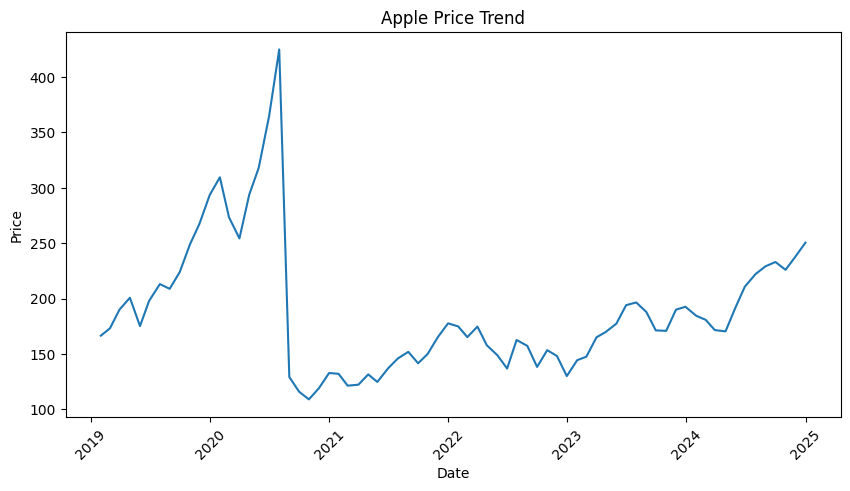

In [223]:
plt.figure(figsize=(10, 5))
plt.plot(market_data_a["date"], market_data_a["prc"])
plt.title(f"{company_a} Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

Short Interpretation of Price Trend

The chart above shows the overall stock price movement of the selected company over the chosen period.

From this visualisation, beginner users can observe whether the company’s price generally increased, decreased, or fluctuated over time.

## 12. Return Analysis

Return is used to show how much the stock price changed during the selected period.

This metric helps beginner users understand whether the stock generally performed positively or negatively over time.

In [224]:
market_data_a[["date", "prc", "ret"]].head()

,date,prc,ret
0,2019-01-31,166.44,0.055154
1,2019-02-28,173.14999,0.044701
2,2019-03-29,189.95,0.097026
3,2019-04-30,200.67,0.056436
4,2019-05-31,175.07001,-0.123735


In [225]:
start_price = market_data_a["prc"].iloc[0]
end_price = market_data_a["prc"].iloc[-1]

total_return = (end_price - start_price) / start_price

print("Start price:", start_price)
print("End price:", end_price)
print("Total return:", total_return)

Start price: 166.44
End price: 250.42
Total return: 0.504566210045662


In [226]:
total_return_pct = total_return * 100
print(f"Total return over the selected period: {total_return_pct:.2f}%")

Total return over the selected period: 50.46%


The result above shows the overall return of the selected company during the chosen period.

A positive return means the stock price increased overall, while a negative return means the stock price decreased overall.

## 13. Volatility Analysis

Volatility shows how strongly the stock price moved up and down during the selected period.

This metric helps beginner users understand whether the company appears relatively stable or relatively risky in market terms.

In [227]:
market_data_a["ret"].describe()

count        72.0
mean     0.029888
std      0.081608
min     -0.123735
25%     -0.035403
50%      0.045365
75%      0.095506
max      0.216309
Name: ret, dtype: Float64

In [228]:
volatility = market_data_a["ret"].std()
print("Volatility:", volatility)

Volatility: 0.08160762061387417


In [229]:
volatility_pct = volatility * 100
print(f"Volatility over the selected period: {volatility_pct:.2f}%")

Volatility over the selected period: 8.16%


The result above shows the volatility of the selected company during the chosen period.

A higher volatility means the stock price moved more sharply up and down, while a lower volatility means the stock price was relatively more stable.

## 14. Fundamental Data Retrieval

This section retrieves basic financial statement data for the selected company.

The aim is to help beginner users understand company fundamentals alongside market performance.

In [230]:
fund_query_a = f"""
SELECT
    tic,
    fyear,
    sale,
    ni,
    act,
    lct,
    invt
FROM comp.funda
WHERE tic = '{ticker_a}'
  AND fyear >= 2019
  AND fyear <= 2024
"""

In [231]:
fund_data_a = db.raw_sql(fund_query_a)
fund_data_a.head()

,tic,fyear,sale,ni,act,lct,invt
0,AAPL,2019,260174.0,55256.0,162819.0,105718.0,4106.0
1,AAPL,2019,260174.0,55256.0,<NA>,<NA>,<NA>
2,AAPL,2020,274515.0,57411.0,143713.0,105392.0,4061.0
3,AAPL,2020,274515.0,57411.0,<NA>,<NA>,<NA>
4,AAPL,2021,365817.0,94680.0,134836.0,125481.0,6580.0


## 15. Initial Inspection of Fundamental Data

The first few rows of the financial statement dataset are displayed below to check whether the required variables have been successfully retrieved and whether the data structure is suitable for analysis.

In [232]:
fund_data_a.info()
fund_data_a.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tic     12 non-null     string 
 1   fyear   12 non-null     Int64  
 2   sale    12 non-null     Float64
 3   ni      12 non-null     Float64
 4   act     6 non-null      Float64
 5   lct     6 non-null      Float64
 6   invt    6 non-null      Float64
dtypes: Float64(5), Int64(1), string(1)
memory usage: 876.0 bytes


,fyear,sale,ni,act,lct,invt
count,12.0,12.0,12.0,6.0,6.0,6.0
mean,2021.5,344859.0,82980.166667,145554.333333,135378.833333,5551.666667
std,1.783765,58176.889723,19791.683409,10756.84771,28297.308398,1367.597407
min,2019.0,260174.0,55256.0,134836.0,105392.0,4061.0
25%,2020.0,274515.0,57411.0,137445.25,110658.75,4316.0
50%,2021.5,374551.0,94208.0,143639.5,135394.5,5638.5
75%,2023.0,391035.0,96995.0,150668.5,151813.5,6517.75
max,2024.0,394328.0,99803.0,162819.0,176392.0,7286.0


In [233]:
fund_data_a["fyear"].value_counts().sort_index()

fyear
2019    2
2020    2
2021    2
2022    2
2023    2
2024    2
Name: count, dtype: Int64

## 16. Fundamental Data Cleaning and Preparation

In this section, the financial statement data are cleaned and prepared for later analysis.

This includes checking duplicate observations, keeping the required variables, and organising the data into a clearer yearly structure.

In [234]:
fund_data_a = fund_data_a.dropna(subset=["act", "lct", "invt"]).drop_duplicates().reset_index(drop=True)
fund_data_a

,tic,fyear,sale,ni,act,lct,invt
0,AAPL,2019,260174.0,55256.0,162819.0,105718.0,4106.0
1,AAPL,2020,274515.0,57411.0,143713.0,105392.0,4061.0
2,AAPL,2021,365817.0,94680.0,134836.0,125481.0,6580.0
3,AAPL,2022,394328.0,99803.0,135405.0,153982.0,4946.0
4,AAPL,2023,383285.0,96995.0,143566.0,145308.0,6331.0
5,AAPL,2024,391035.0,93736.0,152987.0,176392.0,7286.0


In [235]:
fund_data_a["fyear"].value_counts().sort_index()

fyear
2019    1
2020    1
2021    1
2022    1
2023    1
2024    1
Name: count, dtype: Int64

## 17. Revenue Analysis

Revenue is used to show the scale of business activity of the selected company.

This metric helps beginner users understand how large the company’s business operations are over time.

In [236]:
fund_data_a[["fyear", "sale"]]

,fyear,sale
0,2019,260174.0
1,2020,274515.0
2,2021,365817.0
3,2022,394328.0
4,2023,383285.0
5,2024,391035.0


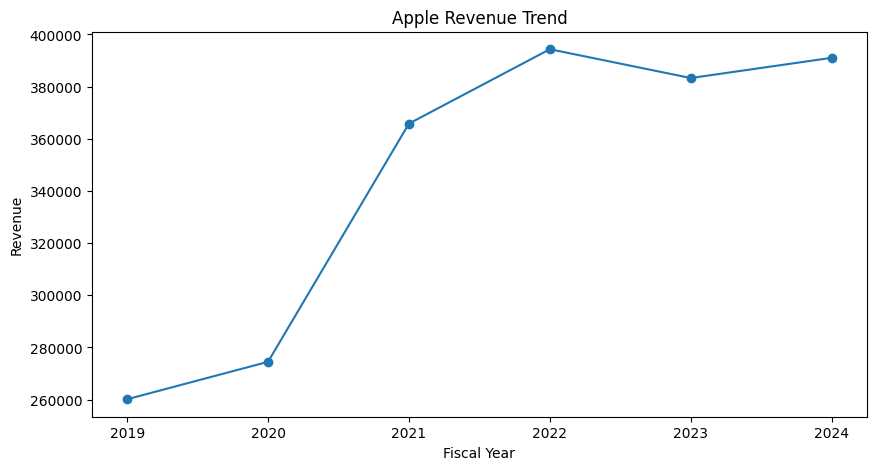

In [237]:
plt.figure(figsize=(10, 5))

plt.plot(fund_data_a["fyear"], fund_data_a["sale"], marker="o")

plt.title(f"{company_a} Revenue Trend")
plt.xlabel("Fiscal Year")
plt.ylabel("Revenue")
plt.xticks(fund_data_a["fyear"])

plt.show()

The chart above shows how the company’s revenue changed across fiscal years.

An increasing revenue trend suggests that the company expanded its business activity over time, while a falling trend suggests that revenue weakened.

## 18. Net Profit Analysis

Net profit is used to show how much earnings the company generated after costs and expenses.

This metric helps beginner users understand whether the company is not only generating revenue, but also turning that revenue into profit.

In [238]:
fund_data_a[["fyear", "ni"]]

,fyear,ni
0,2019,55256.0
1,2020,57411.0
2,2021,94680.0
3,2022,99803.0
4,2023,96995.0
5,2024,93736.0


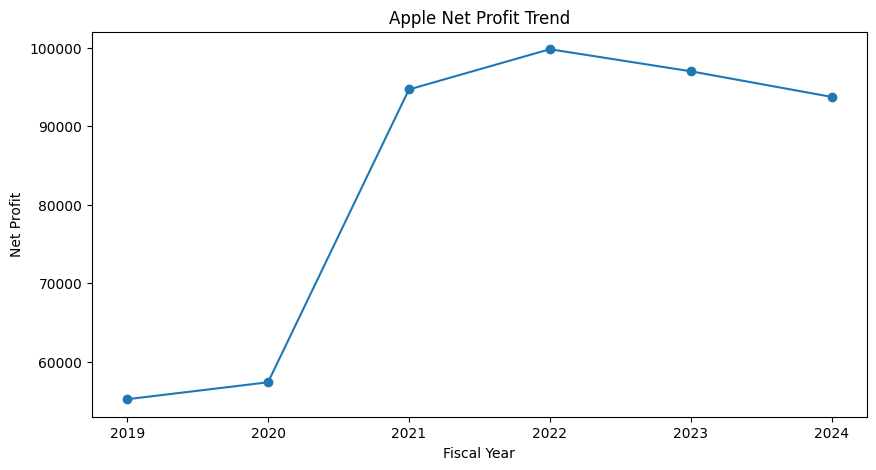

In [239]:
plt.figure(figsize=(10, 5))

plt.plot(fund_data_a["fyear"], fund_data_a["ni"], marker="o")

plt.title(f"{company_a} Net Profit Trend")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Profit")
plt.xticks(fund_data_a["fyear"])

plt.show()

The chart above shows how the company’s net profit changed across fiscal years.

A higher net profit generally means the company kept more earnings after covering its costs and expenses.

## 19. Profit Margin Analysis

Profit margin is calculated as net profit divided by revenue.

This metric helps beginner users understand how much of the company’s revenue is converted into profit.

In [240]:
fund_data_a["profit_margin"] = fund_data_a["ni"] / fund_data_a["sale"]
fund_data_a[["fyear", "sale", "ni", "profit_margin"]]

,fyear,sale,ni,profit_margin
0,2019,260174.0,55256.0,0.212381
1,2020,274515.0,57411.0,0.209136
2,2021,365817.0,94680.0,0.258818
3,2022,394328.0,99803.0,0.253096
4,2023,383285.0,96995.0,0.253062
5,2024,391035.0,93736.0,0.239713


In [241]:
fund_data_a["profit_margin_pct"] = fund_data_a["profit_margin"] * 100
fund_data_a[["fyear", "profit_margin_pct"]]

,fyear,profit_margin_pct
0,2019,21.238095
1,2020,20.913611
2,2021,25.881793
3,2022,25.309641
4,2023,25.306234
5,2024,23.971256


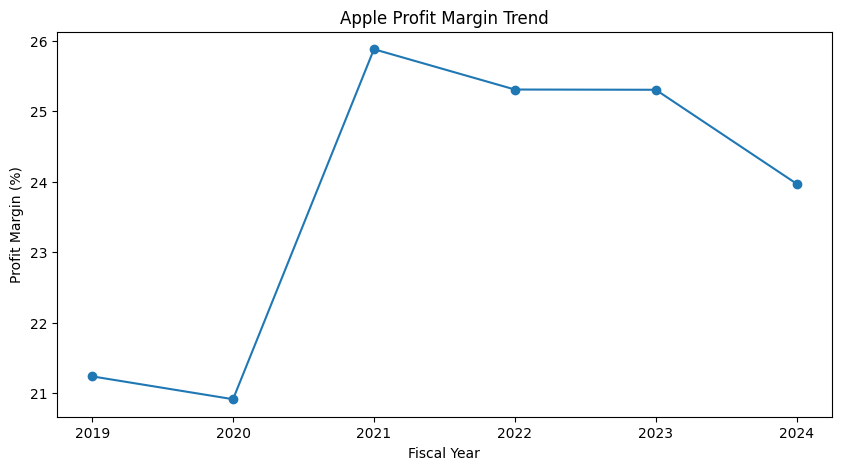

In [242]:
plt.figure(figsize=(10, 5))

plt.plot(fund_data_a["fyear"], fund_data_a["profit_margin_pct"], marker="o")

plt.title(f"{company_a} Profit Margin Trend")
plt.xlabel("Fiscal Year")
plt.ylabel("Profit Margin (%)")
plt.xticks(fund_data_a["fyear"])

plt.show()

The chart above shows the company’s profit margin across fiscal years.

A higher profit margin means that a larger share of the company’s revenue was converted into profit, while a lower profit margin means the company kept less profit from its revenue.

## 20. Quick Ratio Analysis

Quick ratio is calculated as (current assets - inventory) divided by current liabilities.

This metric helps beginner users understand whether the company has relatively strong short-term liquidity.

In [243]:
fund_data_a["quick_ratio"] = (fund_data_a["act"] - fund_data_a["invt"]) / fund_data_a["lct"]
fund_data_a[["fyear", "act", "invt", "lct", "quick_ratio"]]

,fyear,act,invt,lct,quick_ratio
0,2019,162819.0,4106.0,105718.0,1.501286
1,2020,143713.0,4061.0,105392.0,1.325072
2,2021,134836.0,6580.0,125481.0,1.022115
3,2022,135405.0,4946.0,153982.0,0.847235
4,2023,143566.0,6331.0,145308.0,0.944442
5,2024,152987.0,7286.0,176392.0,0.826007


In [244]:
latest_quick_ratio_a = fund_data_a["quick_ratio"].iloc[-1]

if latest_quick_ratio_a < 1:
    quick_ratio_comment_a = "weak short-term liquidity"
elif latest_quick_ratio_a <= 1.5:
    quick_ratio_comment_a = "acceptable short-term liquidity"
else:
    quick_ratio_comment_a = "relatively strong short-term liquidity"

print("Latest Quick Ratio:", round(latest_quick_ratio_a, 2))
print("Interpretation:", quick_ratio_comment_a)

Latest Quick Ratio: 0.83
Interpretation: weak short-term liquidity


In [245]:
fund_data_a["current_ratio"] = fund_data_a["act"] / fund_data_a["lct"]
fund_data_a[["fyear", "act", "lct", "current_ratio"]]

,fyear,act,lct,current_ratio
0,2019,162819.0,105718.0,1.540126
1,2020,143713.0,105392.0,1.363604
2,2021,134836.0,125481.0,1.074553
3,2022,135405.0,153982.0,0.879356
4,2023,143566.0,145308.0,0.988012
5,2024,152987.0,176392.0,0.867313


In [246]:
latest_quick_ratio_a = fund_data_a["quick_ratio"].iloc[-1]
latest_current_ratio_a = fund_data_a["current_ratio"].iloc[-1]
latest_profit_margin_a = fund_data_a["profit_margin_pct"].iloc[-1]

if latest_quick_ratio_a < 1:
    quick_ratio_comment_a = "weak short-term liquidity"
elif latest_quick_ratio_a <= 1.5:
    quick_ratio_comment_a = "acceptable short-term liquidity"
else:
    quick_ratio_comment_a = "relatively strong short-term liquidity"

if latest_current_ratio_a < 1:
    current_ratio_comment_a = "weak current liquidity position"
elif latest_current_ratio_a <= 1.5:
    current_ratio_comment_a = "acceptable current liquidity position"
else:
    current_ratio_comment_a = "relatively strong current liquidity position"

if latest_profit_margin_a < 10:
    profit_margin_comment_a = "weak profitability"
elif latest_profit_margin_a <= 20:
    profit_margin_comment_a = "moderate profitability"
else:
    profit_margin_comment_a = "strong profitability"

print("Latest Quick Ratio:", round(latest_quick_ratio_a, 2))
print("Quick Ratio Interpretation:", quick_ratio_comment_a)

print("Latest Current Ratio:", round(latest_current_ratio_a, 2))
print("Current Ratio Interpretation:", current_ratio_comment_a)

print("Latest Profit Margin (%):", round(latest_profit_margin_a, 2))
print("Profit Margin Interpretation:", profit_margin_comment_a)

Latest Quick Ratio: 0.83
Quick Ratio Interpretation: weak short-term liquidity
Latest Current Ratio: 0.87
Current Ratio Interpretation: weak current liquidity position
Latest Profit Margin (%): 23.97
Profit Margin Interpretation: strong profitability


In [247]:
if total_return_pct < 0:
    return_comment_a = "weak market performance"
elif total_return_pct <= 20:
    return_comment_a = "modest market performance"
else:
    return_comment_a = "strong market performance"

if volatility_pct < 10:
    volatility_comment_a = "relatively stable stock movement"
elif volatility_pct <= 20:
    volatility_comment_a = "moderate stock volatility"
else:
    volatility_comment_a = "high stock volatility"

print("Total Return Interpretation:", return_comment_a)
print("Volatility Interpretation:", volatility_comment_a)

Total Return Interpretation: strong market performance
Volatility Interpretation: relatively stable stock movement


The result above shows the latest quick ratio of the selected company.

A higher quick ratio generally suggests a stronger ability to cover short-term obligations without relying heavily on inventory.

## 20. Market Data Retrieval for the Second Company

This section retrieves market-related data for the second selected company.

The same logic is used in order to support later comparison between the two companies.

In [248]:
market_query_b = f"""
SELECT
    a.date,
    a.permno,
    b.htsymbol,
    a.prc,
    a.ret
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol = '{ticker_b}'
  AND a.date >= '{start_date}'
  AND a.date <= '{end_date}'
"""

In [249]:
market_data_b = db.raw_sql(market_query_b, date_cols=['date'])
market_data_b.head()

,date,permno,htsymbol,prc,ret
0,2019-01-31,17782,SPOT,135.45,0.193392
1,2019-02-28,17782,SPOT,140.14,0.034625
2,2019-03-29,17782,SPOT,138.8,-0.009562
3,2019-04-30,17782,SPOT,135.77,-0.02183
4,2019-05-31,17782,SPOT,125.58,-0.075053


In [250]:
market_data_b = market_data_b.sort_values("date").reset_index(drop=True).copy()
market_data_b.loc[:, "prc"] = market_data_b["prc"].abs()

market_data_b.isna().sum()

date        0
permno      0
htsymbol    0
prc         0
ret         0
dtype: int64

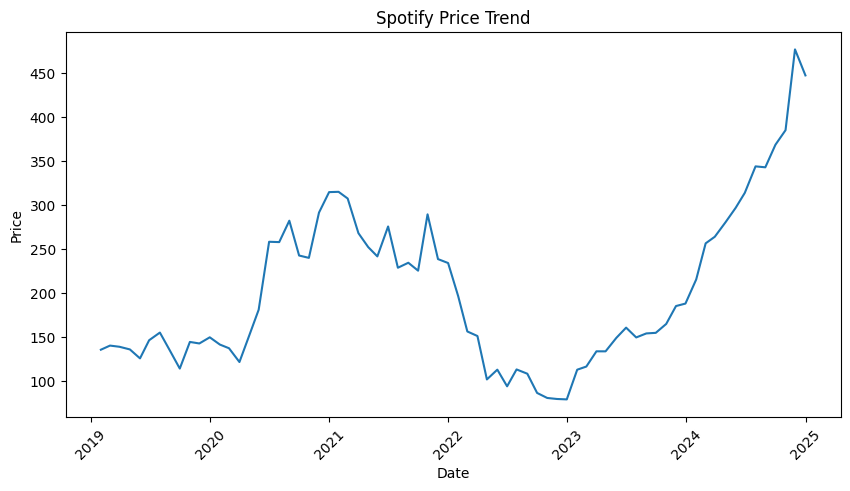

In [251]:
plt.figure(figsize=(10, 5))

plt.plot(market_data_b["date"], market_data_b["prc"])

plt.title(f"{company_b} Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)

plt.show()

In [252]:
start_price_b = market_data_b["prc"].iloc[0]
end_price_b = market_data_b["prc"].iloc[-1]

total_return_b = (end_price_b - start_price_b) / start_price_b
total_return_pct_b = total_return_b * 100

volatility_b = market_data_b["ret"].std()
volatility_pct_b = volatility_b * 100

print(f"{company_b} total return: {total_return_pct_b:.2f}%")
print(f"{company_b} volatility: {volatility_pct_b:.2f}%")

Spotify total return: 230.29%
Spotify volatility: 14.03%


In [253]:
if total_return_pct_b < 0:
    return_comment_b = "weak market performance"
elif total_return_pct_b <= 20:
    return_comment_b = "modest market performance"
else:
    return_comment_b = "strong market performance"

if volatility_pct_b < 10:
    volatility_comment_b = "relatively stable stock movement"
elif volatility_pct_b <= 20:
    volatility_comment_b = "moderate stock volatility"
else:
    volatility_comment_b = "high stock volatility"

print("Total Return Interpretation:", return_comment_b)
print("Volatility Interpretation:", volatility_comment_b)

Total Return Interpretation: strong market performance
Volatility Interpretation: moderate stock volatility


The results above provide a simple assessment of the company’s stock market performance.

Total return helps users judge whether the stock showed weak, modest, or strong overall growth, while volatility helps users understand whether the stock appeared relatively stable or more risky.

## 21. Fundamental Data Retrieval for the Second Company

This section retrieves the financial statement data for the second selected company using the same variables as before.

This allows later comparison of revenue, net profit, and profit margin.

In [254]:
fund_query_b = f"""
SELECT
    tic,
    fyear,
    sale,
    ni,
    act,
    lct,
    invt
FROM comp.funda
WHERE tic = '{ticker_b}'
  AND fyear >= 2019
  AND fyear <= 2024
"""

In [255]:
fund_data_b = db.raw_sql(fund_query_b)
fund_data_b.head()

,tic,fyear,sale,ni,act,lct,invt
0,SPOT,2019,7590.444,-208.726,2503.59,2737.004,0.0
1,SPOT,2020,9498.442,-700.329,2851.943,3495.619,0.0
2,SPOT,2021,10995.665,-38.669,4972.388,3669.013,0.0
3,SPOT,2022,12533.14,-459.559,4651.166,3757.698,0.0
4,SPOT,2023,14642.51,-588.044,5814.117,4520.863,0.0


In [256]:
fund_data_b = fund_data_b.drop_duplicates().reset_index(drop=True)
fund_data_b

,tic,fyear,sale,ni,act,lct,invt
0,SPOT,2019,7590.444,-208.726,2503.59,2737.004,0.0
1,SPOT,2020,9498.442,-700.329,2851.943,3495.619,0.0
2,SPOT,2021,10995.665,-38.669,4972.388,3669.013,0.0
3,SPOT,2022,12533.14,-459.559,4651.166,3757.698,0.0
4,SPOT,2023,14642.51,-588.044,5814.117,4520.863,0.0
5,SPOT,2024,16226.454,1178.186,8674.884,4607.141,0.0


In [257]:
fund_data_b["profit_margin"] = fund_data_b["ni"] / fund_data_b["sale"]

fund_data_b["profit_margin_pct"] = fund_data_b["profit_margin"] * 100

fund_data_b[["fyear", "sale", "ni", "profit_margin_pct"]]

,fyear,sale,ni,profit_margin_pct
0,2019,7590.444,-208.726,-2.749852
1,2020,9498.442,-700.329,-7.373093
2,2021,10995.665,-38.669,-0.351675
3,2022,12533.14,-459.559,-3.666751
4,2023,14642.51,-588.044,-4.016005
5,2024,16226.454,1178.186,7.260896


In [258]:
fund_data_b["quick_ratio"] = (fund_data_b["act"] - fund_data_b["invt"]) / fund_data_b["lct"]
fund_data_b[["fyear", "act", "invt", "lct", "quick_ratio"]]

,fyear,act,invt,lct,quick_ratio
0,2019,2503.59,0.0,2737.004,0.914719
1,2020,2851.943,0.0,3495.619,0.815862
2,2021,4972.388,0.0,3669.013,1.355239
3,2022,4651.166,0.0,3757.698,1.23777
4,2023,5814.117,0.0,4520.863,1.286064
5,2024,8674.884,0.0,4607.141,1.882921


In [259]:
fund_data_b["current_ratio"] = fund_data_b["act"] / fund_data_b["lct"]
fund_data_b[["fyear", "act", "lct", "current_ratio"]]

,fyear,act,lct,current_ratio
0,2019,2503.59,2737.004,0.914719
1,2020,2851.943,3495.619,0.815862
2,2021,4972.388,3669.013,1.355239
3,2022,4651.166,3757.698,1.23777
4,2023,5814.117,4520.863,1.286064
5,2024,8674.884,4607.141,1.882921


In [260]:
latest_quick_ratio_b = fund_data_b["quick_ratio"].iloc[-1]
latest_current_ratio_b = fund_data_b["current_ratio"].iloc[-1]
latest_profit_margin_b = fund_data_b["profit_margin_pct"].iloc[-1]

if latest_quick_ratio_b < 1:
    quick_ratio_comment_b = "weak short-term liquidity"
elif latest_quick_ratio_b <= 1.5:
    quick_ratio_comment_b = "acceptable short-term liquidity"
else:
    quick_ratio_comment_b = "relatively strong short-term liquidity"

if latest_current_ratio_b < 1:
    current_ratio_comment_b = "weak current liquidity position"
elif latest_current_ratio_b <= 1.5:
    current_ratio_comment_b = "acceptable current liquidity position"
else:
    current_ratio_comment_b = "relatively strong current liquidity position"

if latest_profit_margin_b < 10:
    profit_margin_comment_b = "weak profitability"
elif latest_profit_margin_b <= 20:
    profit_margin_comment_b = "moderate profitability"
else:
    profit_margin_comment_b = "strong profitability"

print("Latest Quick Ratio:", round(latest_quick_ratio_b, 2))
print("Quick Ratio Interpretation:", quick_ratio_comment_b)

print("Latest Current Ratio:", round(latest_current_ratio_b, 2))
print("Current Ratio Interpretation:", current_ratio_comment_b)

print("Latest Profit Margin (%):", round(latest_profit_margin_b, 2))
print("Profit Margin Interpretation:", profit_margin_comment_b)

Latest Quick Ratio: 1.88
Quick Ratio Interpretation: relatively strong short-term liquidity
Latest Current Ratio: 1.88
Current Ratio Interpretation: relatively strong current liquidity position
Latest Profit Margin (%): 7.26
Profit Margin Interpretation: weak profitability


The results above provide a simple assessment of the company’s profitability and liquidity position.

Profit margin is used to judge profitability, while quick ratio and current ratio are used to assess whether the company appears relatively weak, acceptable, or strong in short-term liquidity.

## 22. Combined Comparison

This section compares the two selected companies using both market data and financial statement data.

The aim is to help beginner users understand that market performance and company fundamentals are related but not identical.

In [261]:
comparison_summary = pd.DataFrame({
    "Company": [company_a, company_b],
    "Ticker": [ticker_a, ticker_b],
    "Total Return (%)": [total_return_pct, total_return_pct_b],
    "Volatility (%)": [volatility_pct, volatility_pct_b],
    "Revenue (latest year)": [
        fund_data_a["sale"].iloc[-1],
        fund_data_b["sale"].iloc[-1]
    ],
    "Net Profit (latest year)": [
        fund_data_a["ni"].iloc[-1],
        fund_data_b["ni"].iloc[-1]
    ],
    "Profit Margin (%)": [
        fund_data_a["profit_margin_pct"].iloc[-1],
        fund_data_b["profit_margin_pct"].iloc[-1]
    ],
    "Quick Ratio": [
        fund_data_a["quick_ratio"].iloc[-1],
        fund_data_b["quick_ratio"].iloc[-1]
    ],
    "Current Ratio": [
        fund_data_a["current_ratio"].iloc[-1],
        fund_data_b["current_ratio"].iloc[-1]
    ]
})

comparison_summary

,Company,Ticker,Total Return (%),Volatility (%),Revenue (latest year),Net Profit (latest year),Profit Margin (%),Quick Ratio,Current Ratio
0,Apple,AAPL,50.456621,8.160762,391035.000,93736.000,23.971256,0.826007,0.867313
1,Spotify,SPOT,230.291621,14.032642,16226.454,1178.186,7.260896,1.882921,1.882921


The table above compares the two selected companies using both market-based indicators and financial statement indicators.

In addition to return, volatility, revenue, net profit, and profit margin, the table also includes quick ratio and current ratio so that beginner users can compare profitability, liquidity, and stock market behaviour together.

## 23. Concept Explorer

This section explains the key concepts used in the project.

The purpose is to help beginner users understand the meaning of the most important indicators shown in the analysis.

In [262]:
concept_explanations = {
    "Company": {
        "meaning": "Company refers to the business selected for analysis in the project.",
        "importance": "It is the main object of the analysis and helps users focus on one business at a time.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, users select one or two companies to explore their market performance and fundamentals."
    },
    "Ticker": {
        "meaning": "Ticker is the short stock code used to identify a company in the stock market.",
        "importance": "It is needed to retrieve market and financial statement data from WRDS.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, the ticker is automatically matched after the user selects a company name."
    },
    "Date Range": {
        "meaning": "Date range refers to the selected start date and end date used in the analysis.",
        "importance": "It defines the period over which the stock data and financial data are analysed.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, the selected date range determines which market observations and fiscal years are included."
    },
    "Fiscal Year": {
        "meaning": "Fiscal year is the reporting year used in the company’s financial statements.",
        "importance": "It helps users compare company performance across different reporting periods.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, fiscal year is used to organise revenue, net profit, and ratio data."
    },
    "Price": {
        "meaning": "Price is the market value of one share of the company at a given time.",
        "importance": "It helps users see how the stock moves over time.",
        "formula": "Price is directly retrieved from the market dataset rather than calculated here.",
        "project": "In this project, price is used to draw the stock price trend chart."
    },
    "Price Trend": {
        "meaning": "Price trend refers to the overall direction of stock price movement over time.",
        "importance": "It helps users identify whether the stock generally increased, decreased, or fluctuated.",
        "formula": "Based on the time series of stock prices across the selected date range.",
        "project": "In this project, price trend is visualised through a line chart based on historical market data."
    },
    "Trend": {
        "meaning": "Trend refers to the general direction of change in a variable over time.",
        "importance": "It helps users judge whether an indicator is increasing, decreasing, or fluctuating.",
        "formula": "Trend is interpreted from the pattern of values across time rather than one single formula.",
        "project": "In this project, trend is shown through line charts for price, revenue, net profit, profit margin, and liquidity ratios."
    },
    "Return": {
        "meaning": "Return shows how much the stock price changed over a period of time.",
        "importance": "It helps beginners understand whether a stock performed positively or negatively.",
        "formula": "Return = (Ending Price - Starting Price) / Starting Price",
        "project": "In this project, return is used as the basis for total return analysis."
    },
    "Total Return": {
        "meaning": "Total return is the overall percentage change in stock price over the selected period.",
        "importance": "It helps users compare overall stock performance across companies.",
        "formula": "Total Return (%) = [(Ending Price - Starting Price) / Starting Price] × 100",
        "project": "In this project, total return is displayed in the market summary and comparison table."
    },
    "Volatility": {
        "meaning": "Volatility shows how strongly the stock price moved up and down.",
        "importance": "It helps users understand whether a company appears relatively stable or risky.",
        "formula": "Volatility = standard deviation of returns; Volatility (%) = std(return) × 100",
        "project": "In this project, volatility is calculated from return data to show market fluctuation."
    },
    "Risk": {
        "meaning": "Risk refers to the uncertainty or instability in investment outcomes.",
        "importance": "It helps users understand that stronger price fluctuation may mean less stability.",
        "formula": "In this project, risk is mainly represented by Volatility.",
        "project": "In this project, users interpret market risk mainly through stock volatility."
    },
    "Market Summary": {
        "meaning": "Market summary is the section that reports the key market indicators of the selected company.",
        "importance": "It gives users a short overview of stock performance before deeper interpretation.",
        "formula": "Main metrics shown here include Total Return and Volatility.",
        "project": "In this project, the market summary explains stock growth and price fluctuation."
    },
    "Revenue": {
        "meaning": "Revenue is the total income generated from the company’s business activities.",
        "importance": "It helps users understand the scale of the company’s operations.",
        "formula": "Revenue is directly retrieved from the financial statement dataset rather than calculated here.",
        "project": "In this project, revenue is used to show changes in business size across fiscal years."
    },
    "Net Profit": {
        "meaning": "Net profit is the amount of earnings left after costs and expenses are deducted.",
        "importance": "It helps users understand whether the company is making money.",
        "formula": "Net Profit is directly retrieved from the financial statement dataset rather than calculated here.",
        "project": "In this project, net profit is used to show the company’s profitability over time."
    },
    "Profit Margin": {
        "meaning": "Profit margin is the percentage of revenue that is converted into profit.",
        "importance": "It helps users understand how efficiently the company turns revenue into earnings.",
        "formula": "Profit Margin = Net Profit / Revenue; Profit Margin (%) = (Net Profit / Revenue) × 100",
        "project": "In this project, profit margin is used to compare profitability between companies."
    },
    "Quick Ratio": {
        "meaning": "Quick ratio is a liquidity indicator based on liquid current assets relative to current liabilities.",
        "importance": "It helps users understand whether a company can cover short-term obligations without relying heavily on inventory.",
        "formula": "Quick Ratio = (Current Assets - Inventory) / Current Liabilities",
        "project": "In this project, quick ratio is used to compare short-term liquidity strength."
    },
    "Current Ratio": {
        "meaning": "Current ratio compares current assets with current liabilities.",
        "importance": "It helps users understand the company’s short-term liquidity position.",
        "formula": "Current Ratio = Current Assets / Current Liabilities",
        "project": "In this project, current ratio is used together with quick ratio to assess liquidity."
    },
    "Liquidity": {
        "meaning": "Liquidity refers to the company’s ability to meet short-term obligations.",
        "importance": "It helps users judge whether the company appears financially flexible in the short term.",
        "formula": "Main liquidity indicators here: Quick Ratio and Current Ratio",
        "project": "In this project, liquidity is assessed mainly through quick ratio and current ratio."
    },
    "Profitability": {
        "meaning": "Profitability refers to the company’s ability to generate earnings from its operations.",
        "importance": "It helps users judge whether the company turns revenue into meaningful profit.",
        "formula": "Main profitability indicator here: Profit Margin = Net Profit / Revenue",
        "project": "In this project, profitability is mainly represented by profit margin and net profit."
    },
    "Fundamentals": {
        "meaning": "Fundamentals refer to the basic financial condition and operating performance of a company.",
        "importance": "They help users understand the company beyond stock price movements.",
        "formula": "Main fundamentals used here: Revenue, Net Profit, Profit Margin, Quick Ratio, Current Ratio",
        "project": "In this project, fundamentals are represented by revenue, net profit, profitability, and liquidity indicators."
    },
    "Fundamentals Summary": {
        "meaning": "Fundamentals summary is the section that reports the latest key financial indicators of the selected company.",
        "importance": "It gives users a short overview of the company’s business condition and financial strength.",
        "formula": "Main metrics shown here: Revenue, Net Profit, Profit Margin, Quick Ratio, Current Ratio",
        "project": "In this project, the fundamentals summary helps users interpret business performance more quickly."
    },
    "Comparison": {
        "meaning": "Comparison means evaluating two companies using the same indicators.",
        "importance": "It helps users identify differences in market performance and business fundamentals.",
        "formula": "Comparison is based on side-by-side indicator values rather than one formula.",
        "project": "In this project, comparison is used to show that stock performance and financial strength may differ across companies."
    },
    "Comparison Summary": {
        "meaning": "Comparison summary is the table that puts two selected companies side by side using the same measures.",
        "importance": "It helps users compare return, risk, profitability, and liquidity in one place.",
        "formula": "Main measures compared: Total Return, Volatility, Revenue, Net Profit, Profit Margin, Quick Ratio, Current Ratio",
        "project": "In this project, the comparison summary is a key user-facing output."
    },
    "Market Performance": {
        "meaning": "Market performance refers to how a company performs in the stock market.",
        "importance": "It helps users understand price movement, return, and market risk.",
        "formula": "Main market indicators here: Price Trend, Total Return, Volatility",
        "project": "In this project, market performance is represented by price trend, return, and volatility."
    },
    "Beginner Mode": {
        "meaning": "Beginner mode is a simpler explanation mode designed for new users.",
        "importance": "It lowers the learning barrier and makes the results easier to understand.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, beginner mode provides shorter and clearer explanations of the indicators."
    },
    "Deeper Mode": {
        "meaning": "Deeper mode is a more detailed explanation mode for users who want stronger analytical understanding.",
        "importance": "It allows users to explore the same results with slightly more depth.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, deeper mode provides more analytical explanations of indicators and company comparison."
    },
    "Result Interpretation": {
        "meaning": "Result interpretation is the explanation layer that turns numerical outputs into readable conclusions.",
        "importance": "It helps users understand what the calculated indicators mean in practice.",
        "formula": "Not a calculated indicator. It is based on the combined reading of market and financial indicators.",
        "project": "In this project, result interpretation is available in Beginner mode and Deeper mode."
    },
    "Key Takeaways": {
        "meaning": "Key takeaways are short beginner-friendly lessons summarised from the analysis results.",
        "importance": "They help users focus on the most important insights without reading every chart or table in detail.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, key takeaways summarise what beginner users should learn from the comparison of market performance and fundamentals."
    },
    "Learning Report": {
        "meaning": "Learning report is a short summary written for beginner users based on the analysis results.",
        "importance": "It helps turn charts and numbers into easier conclusions.",
        "formula": "Not a calculated indicator.",
        "project": "In this project, the learning report combines market indicators and financial statement indicators into a simple summary."
    }
}

In [263]:
concept_explanations["Return"]

{'meaning': 'Return shows how much the stock price changed over a period of time.',
 'importance': 'It helps beginners understand whether a stock performed positively or negatively.',
 'formula': 'Return = (Ending Price - Starting Price) / Starting Price',
 'project': 'In this project, return is used as the basis for total return analysis.'}

## 24. Beginner vs Deeper Result Interpretation

The final dashboard includes two interpretation modes:

- **Beginner mode**: a simpler and more direct explanation of the results
- **Deeper mode**: a more professional and more in-depth explanation of the results

Both modes consider not only market indicators, but also the company’s operating condition. However, Beginner mode focuses on simpler conclusions, while Deeper mode provides more analytical interpretation.

This design is important because the final product is intended for beginner users with different levels of prior financial knowledge.concept_table = pd.DataFrame(concept_explanations).T
concept_table

In [265]:
if total_return_pct > total_return_pct_b:
    higher_return_company = company_a
else:
    higher_return_company = company_b

if volatility_pct > volatility_pct_b:
    higher_volatility_company = company_a
else:
    higher_volatility_company = company_b

if fund_data_a["profit_margin_pct"].iloc[-1] > fund_data_b["profit_margin_pct"].iloc[-1]:
    higher_profit_margin_company = company_a
else:
    higher_profit_margin_company = company_b

if fund_data_a["quick_ratio"].iloc[-1] > fund_data_b["quick_ratio"].iloc[-1]:
    higher_quick_ratio_company = company_a
else:
    higher_quick_ratio_company = company_b

if fund_data_a["current_ratio"].iloc[-1] > fund_data_b["current_ratio"].iloc[-1]:
    higher_current_ratio_company = company_a
else:
    higher_current_ratio_company = company_b

if higher_return_company == higher_volatility_company:
    comparison_market_sentence = f"{higher_return_company} performed better in stock market return, but it also showed stronger price fluctuations."
else:
    comparison_market_sentence = f"{higher_return_company} performed better in stock market return, while {higher_volatility_company} showed stronger price fluctuations."

if higher_quick_ratio_company == higher_current_ratio_company:
    comparison_liquidity_sentence = f"{higher_quick_ratio_company} showed relatively stronger liquidity positions."
else:
    comparison_liquidity_sentence = f"{higher_quick_ratio_company} showed a stronger quick ratio, while {higher_current_ratio_company} showed a stronger current ratio."

result_explanations = {
    "Single Company": {
        "Beginner": f"""
{company_a} showed {return_comment_a} over the selected period.

Its total return was {total_return_pct:.2f}%, and its volatility was {volatility_pct:.2f}%, which suggests {volatility_comment_a}.

From the financial statement side, the latest profit margin was {fund_data_a['profit_margin_pct'].iloc[-1]:.2f}%, the quick ratio was {fund_data_a['quick_ratio'].iloc[-1]:.2f}, and the current ratio was {fund_data_a['current_ratio'].iloc[-1]:.2f}.

This suggests {profit_margin_comment_a}, {quick_ratio_comment_a}, and {current_ratio_comment_a}.
""",
        "Deeper": f"""
{company_a} generated a total return of {total_return_pct:.2f}% over the selected period, which indicates {return_comment_a}. Its volatility was {volatility_pct:.2f}%, suggesting {volatility_comment_a}.

From the operating perspective, the company reported a latest profit margin of {fund_data_a['profit_margin_pct'].iloc[-1]:.2f}%, a quick ratio of {fund_data_a['quick_ratio'].iloc[-1]:.2f}, and a current ratio of {fund_data_a['current_ratio'].iloc[-1]:.2f}.

Taken together, these results suggest {profit_margin_comment_a}. In addition, the liquidity indicators imply {quick_ratio_comment_a} and {current_ratio_comment_a}. This means the company should be assessed using both market performance and financial condition.
"""
    },
    "Company Comparison": {
        "Beginner": f"""
{company_a} and {company_b} showed different patterns in both stock market performance and company fundamentals.

{company_a} had a total return of {total_return_pct:.2f}% and volatility of {volatility_pct:.2f}%, while {company_b} had a total return of {total_return_pct_b:.2f}% and volatility of {volatility_pct_b:.2f}%.

This means that {comparison_market_sentence}

From the financial statement side, {company_a} had a profit margin of {fund_data_a['profit_margin_pct'].iloc[-1]:.2f}%, a quick ratio of {fund_data_a['quick_ratio'].iloc[-1]:.2f}, and a current ratio of {fund_data_a['current_ratio'].iloc[-1]:.2f}. {company_b} had a profit margin of {fund_data_b['profit_margin_pct'].iloc[-1]:.2f}%, a quick ratio of {fund_data_b['quick_ratio'].iloc[-1]:.2f}, and a current ratio of {fund_data_b['current_ratio'].iloc[-1]:.2f}.

This suggests that {higher_profit_margin_company} was stronger in profitability. In addition, {comparison_liquidity_sentence}
""",
        "Deeper": f"""
The comparison between {company_a} and {company_b} shows a clear difference between market performance and operating fundamentals.

In market terms, {company_a} generated a total return of {total_return_pct:.2f}% with volatility of {volatility_pct:.2f}%, whereas {company_b} generated a total return of {total_return_pct_b:.2f}% with volatility of {volatility_pct_b:.2f}. {comparison_market_sentence}

From the perspective of operating performance, {company_a} reported a profit margin of {fund_data_a['profit_margin_pct'].iloc[-1]:.2f}%, a quick ratio of {fund_data_a['quick_ratio'].iloc[-1]:.2f}, and a current ratio of {fund_data_a['current_ratio'].iloc[-1]:.2f}. By contrast, {company_b} reported a profit margin of {fund_data_b['profit_margin_pct'].iloc[-1]:.2f}%, a quick ratio of {fund_data_b['quick_ratio'].iloc[-1]:.2f}, and a current ratio of {fund_data_b['current_ratio'].iloc[-1]:.2f}.

These results suggest that {higher_profit_margin_company} had stronger profitability. In addition, {comparison_liquidity_sentence} This comparison demonstrates that return, risk, profitability, and liquidity can move in different directions.
"""
    }
}

In [266]:
pd.DataFrame(result_explanations).T

,Beginner,Deeper
Single Company,\nApple showed strong market performance over ...,\nApple generated a total return of 50.46% ove...
Company Comparison,\nApple and Spotify showed different patterns ...,\nThe comparison between Apple and Spotify sho...


In [267]:
print("Beginner mode - Single Company")
print(result_explanations["Single Company"]["Beginner"])

print("\n" + "="*80 + "\n")

print("Deeper mode - Single Company")
print(result_explanations["Single Company"]["Deeper"])

print("\n" + "="*80 + "\n")

print("Beginner mode - Company Comparison")
print(result_explanations["Company Comparison"]["Beginner"])

print("\n" + "="*80 + "\n")

print("Deeper mode - Company Comparison")
print(result_explanations["Company Comparison"]["Deeper"])

Beginner mode - Single Company

Apple showed strong market performance over the selected period.

Its total return was 50.46%, and its volatility was 8.16%, which suggests relatively stable stock movement.

From the financial statement side, the latest profit margin was 23.97%, the quick ratio was 0.83, and the current ratio was 0.87.

This suggests strong profitability, weak short-term liquidity, and weak current liquidity position.



Deeper mode - Single Company

Apple generated a total return of 50.46% over the selected period, which indicates strong market performance. Its volatility was 8.16%, suggesting relatively stable stock movement.

From the operating perspective, the company reported a latest profit margin of 23.97%, a quick ratio of 0.83, and a current ratio of 0.87.

Taken together, these results suggest strong profitability. In addition, the liquidity indicators imply weak short-term liquidity and weak current liquidity position. This means the company should be assesse

## 25. Key Takeaways for Beginners

The final dashboard includes a Key Takeaways section to summarise the most important lessons from the analysis.

This section helps beginner users focus on the main conclusions without needing to interpret every chart, ratio, and comparison by themselves.

In the final product, the Key Takeaways section highlights that:

- stock return and volatility may move together
- profitability and liquidity may differ across companies
- market performance and financial fundamentals do not always move in the same direction

This makes the tool more educational and easier to use.

In [268]:
if higher_return_company == higher_volatility_company:
    takeaway_market_sentence = f"{higher_return_company} showed stronger stock return, but it also showed higher volatility."
else:
    takeaway_market_sentence = f"{higher_return_company} showed stronger stock return, while {higher_volatility_company} showed higher volatility."

if higher_quick_ratio_company == higher_current_ratio_company:
    takeaway_liquidity_sentence = f"{higher_quick_ratio_company} showed relatively stronger short-term liquidity."
else:
    takeaway_liquidity_sentence = f"{higher_quick_ratio_company} showed a stronger quick ratio, while {higher_current_ratio_company} showed a stronger current ratio."

key_takeaways = f"""
Key takeaways for beginners:

1. {takeaway_market_sentence}
2. {higher_profit_margin_company} showed stronger profitability.
3. {takeaway_liquidity_sentence}
4. This comparison suggests that stock market performance, profitability, and liquidity do not always move in the same direction.
5. Beginner investors should compare market indicators and financial indicators together.
"""

print(key_takeaways)


Key takeaways for beginners:

1. Spotify showed stronger stock return, but it also showed higher volatility.
2. Apple showed stronger profitability.
3. Spotify showed relatively stronger short-term liquidity.
4. This comparison suggests that stock market performance, profitability, and liquidity do not always move in the same direction.
5. Beginner investors should compare market indicators and financial indicators together.



## 26. Final Product Features

The final Streamlit dashboard includes the following user-facing features:

- Company A and optional Company B selection
- user-selected date range
- stock price trend chart
- market summary including total return and volatility
- fundamentals table with clearer labels and units
- fundamentals trend chart
- fundamentals summary
- company comparison table
- concept explorer
- Beginner mode and Deeper mode interpretation
- Key Takeaways for beginner users

The analytical notebook represents the full WRDS-based data workflow, while the final app represents the deployed user-facing version based on exported CSV files.

## 27. Limitations

This project has several limitations.

First, the analysis only includes a limited number of companies, so it does not represent the full stock market.

Second, although the project covers both market indicators and some key financial indicators, it still does not include many other useful measures, such as valuation ratios, leverage indicators, or cash flow measures.

Third, the interpretation is simplified for beginner users, which means some financial and market details are not discussed in full depth.

Fourth, the final deployed app uses exported CSV files rather than live WRDS queries, which improves stability but means that the app is not a live database querying tool.

Finally, the tool is designed for educational purposes only. It helps users understand companies more clearly, but it does not provide formal investment advice.

## 28. Possible Improvements

This project can be improved in several ways in the future.

First, more companies can be added to the dropdown menu so that users can explore a wider range of firms.

Second, more financial and market indicators can be included, such as valuation ratios, leverage ratios, and cash flow measures, in order to provide a more complete picture of company performance.

Third, the interpretation layer can be further improved to generate more personalised explanations based on different user needs and levels of prior knowledge.

Fourth, the interface design can be further improved to make the final dashboard more polished and visually appealing.

Fifth, the concept learning section can be expanded further so that users can explore a larger set of financial and investment-related terms.

Finally, the deployment and data update workflow can be improved so that the app can be refreshed more easily when new processed datasets are prepared.

## 29. Conclusion

This project develops the analytical foundation of a beginner-friendly company learning tool.

Using WRDS market data and financial statement data, it compares companies from both a stock market perspective and a business fundamentals perspective.

The project shows that stock market performance and financial condition are related but not always consistent. A company with stronger stock return may also have higher volatility, while a company with stronger profitability or liquidity may not always deliver the highest market return.

In the final product design, these analytical results were transformed into a beginner-friendly Streamlit dashboard with company selection, trend charts, comparison functions, concept explanations, interpretation modes, and key takeaways.

Overall, this notebook demonstrates how data analysis, financial interpretation, and beginner-oriented explanation can be combined into a learning-focused investment tool.

## 30. Deployment Note

For analytical development, this project used WRDS data directly in the notebook, including data retrieval, cleaning, calculation, and interpretation.

For the final deployed Streamlit version, the app was adjusted to read exported CSV files instead of querying WRDS live. This change was made to improve deployment stability, loading speed, and accessibility for end users.

Therefore, the notebook shows the full analytical workflow, while the deployed app represents a lightweight user-facing product version based on the processed outputs.

In [65]:
db.close()